## Assignment Setup

In this project, you will explore how visualizations, distributions, and disaggregations can reveal underlying trends in the data. We will focus on UC Berkeley admissions, past and present.

In [466]:
# Run this cell.
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

import warnings
warnings.simplefilter('ignore')

**Note:** It's a good idea to have the [Python Reference Sheet](https://data6.org/su24/reference/) open while working on the assignment in the event you have any questions.

You can also easily see the documentation for a function by either:
- typing the name of the function on a new line, followed by a `?`, and running the cell
- typing the name of the function anywhere in a code cell and hitting `Shift + Tab` on your keyboard

Try it out below! Just add a `?` to the end of the line.

In [467]:
Table.where

<function datascience.tables.Table.where(self, column_or_label, value_or_predicate=None, other=None)>

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# [Present] Part 1: UC Berkeley Undergraduate Admissions, 2024

<br></br>
<hr style="border: 1px solid #fdb515;" />

## Question 1: Unboxing the dataset

In this part of the assignment, we explore UC Berkeley's undergraduate admissions numbers for the freshman Fall 2024 class. The data we'll work with in this question comes from [this public webpage](https://www.universityofcalifornia.edu/infocenter/admissions-source-school).

Run the cell below to load in our data as a Table, `schools_full`.

In [468]:
schools_full = Table.read_table('firstyear_admissions_2024.csv')
schools_full

School,City,Region,Applied,Admitted,Enrolled
21ST CENTURY CHARTER SCHL GARY,Gary,IN,0,0,0
21ST CENTURY EXPERIMENTAL SCH,nan,nan,125,104,33
32ND USC PERFORMING ARTS SCHOOL,Los Angeles,Los Angeles,0,0,0
A & M CONSOLIDATED HIGH SCHOOL,College Station,TX,5,0,0
A B LUCAS SECONDARY SCHOOL,nan,nan,0,0,0
A B MILLER HIGH SCHOOL,Fontana,San Bernardino,81,67,27
A BEKA ACADEMY VIDEO FOR HOMES,Pensacola,FL,5,4,0
A BOWMAN COLLEGIATE INSTITUTE,nan,nan,0,0,0
A C DAVIS SENIOR HIGH SCHOOL,Yakima,WA,0,0,0
A CRAWFORD MOSLEY HIGH SCHOOL,Lynn Haven,FL,0,0,0


Each row corresponds to a high school. For each high school, we have the following information:
- `'School'`: The name of the high school.
- `'City'`: The city the high school is located in.
- `'Region'`: The county the high school is located in if the high school is in California, **or** the state in which the high school is if the high school is elsewhere in the US.
- `'Applied'`: The number of first-year students who applied to UC Berkeley from that high school for admission that year.
- `'Admitted'`: The number of first-year students who were admitted to UC Berkeley from that high school for admission that year.
- `'Enrolled'`: The number of first-year students who actually chose to attend UC Berkeley from that high school that year.

Applied, Admitted, and Enrolled numbers are all with respect to Fall 2024.

---

## Question 1a

How many schools are in our dataset? Use `schools_full`.

In [469]:
num_schools = schools_full.num_rows # SOLUTION
num_schools

11536

In [470]:
answer = schools_full.num_rows
num_schools == answer

True

Many schools seem to have the same name. For instance, the name 'ABRAHAM LINCOLN HIGH SCHOOL' corresponds to five different high schools: in Los Angeles, San Francisco, Santa Clara in California (CA); and in Council Bluffs and Des Moines, Iowa (IA):

In [471]:
schools_full.where("School", "ABRAHAM LINCOLN HIGH SCHOOL")

School,City,Region,Applied,Admitted,Enrolled
ABRAHAM LINCOLN HIGH SCHOOL,Council Bluffs,IA,0,0,0
ABRAHAM LINCOLN HIGH SCHOOL,Des Moines,IA,0,0,0
ABRAHAM LINCOLN HIGH SCHOOL,Los Angeles,Los Angeles,74,55,18
ABRAHAM LINCOLN HIGH SCHOOL,San Francisco,San Francisco,249,166,98
ABRAHAM LINCOLN HIGH SCHOOL,San Jose,Santa Clara,104,73,37


---

## Question 1b(i)

Create a table `count_by_school_name` that counts the number of schools for each school name. Your table should have the following format:

| School | count | 
| --- | --- |
| ... | ... |
| ABRAHAM LINCOLN HIGH SCHOOL | 5 | 
| ... | ... |

In [472]:
count_by_school_name = schools_full.group("School") # SOLUTION
count_by_school_name

School,count
21ST CENTURY CHARTER SCHL GARY,1
21ST CENTURY EXPERIMENTAL SCH,1
32ND USC PERFORMING ARTS SCHOOL,1
A & M CONSOLIDATED HIGH SCHOOL,1
A B LUCAS SECONDARY SCHOOL,1
A B MILLER HIGH SCHOOL,1
A BEKA ACADEMY VIDEO FOR HOMES,1
A BOWMAN COLLEGIATE INSTITUTE,1
A C DAVIS SENIOR HIGH SCHOOL,1
A CRAWFORD MOSLEY HIGH SCHOOL,1


In [473]:
isinstance(count_by_school_name, Table)

True

In [474]:
[s.lower() for s in count_by_school_name.labels] == [s.lower() for s in ("School", "count")]

True

In [475]:
answer = 10548
count_by_school_name.num_rows == answer

True

---

## Question 1b(ii)

Using `count_by_school_name`, count the number of schools that share a name with at least one other school in our dataset, and assign this to `num_same_name`. In other words, count the number of schools that **do not** have a unique name in our dataset.

_Hint_: How can you filter rows from a table with `where`? How does `count_by_school_name` tell you if a school's name is unique?

In [476]:
num_same_name = count_by_school_name.where("count", are.above(1)).num_rows # SOLUTION
num_same_name

550

In [477]:
isinstance(num_same_name, int)

True

In [478]:
answer = 550
num_same_name == answer

True

Next, let's examine the city names. 

---

## Question 1c(i)

What is the most common city in the dataset? Create a table `count_by_city` that counts the number of schools in each city **and** region, in order of **most schools first**. Your table should look like this (here are the first few rows):

| City |	Region |	count |
| --- | --- | --- |
| nan | nan | 2477 |
| Los Angeles | Los Angeles | 173 | 
| New York | NY | 92 |
| ... | ... | ... |

_Hint_: See the [Data 6 Python Reference](https://data6.org/notes/reference) and course notes for how to group rows by multiple attributes.

In [479]:
count_by_city = schools_full.group(["City", "Region"]).sort("count", descending=True) # SOLUTION
count_by_city

City,Region,count
nan,nan,2477
Los Angeles,Los Angeles,173
New York,NY,92
Houston,TX,83
San Diego,San Diego,77
Chicago,IL,73
San Antonio,TX,52
San Jose,Santa Clara,49
Las Vegas,NV,46
Phoenix,AZ,46


In [480]:
isinstance(count_by_city, Table)

True

In [481]:
count_by_city.num_rows == 4079

True

In [482]:
[s.lower() for s in count_by_city.labels] == [s.lower() for s in ("City", "Region", "count")]

True

In [483]:
count_by_city.column("City").item(0) == "nan"

True

In [484]:
count_by_city.column("Region").item(0) == "nan"

True

In [485]:
count_by_city.column("count").item(0) == 2477

True

In [486]:
# HIDDEN
count_by_city.column("City").item(7) == "San Jose"

True

In [487]:
# HIDDEN
count_by_city.column("Region").item(7) == "Santa Clara"

True

In [488]:
# HIDDEN
count_by_city.column("count").item(7) == 49

True

It seems like the most common city is called `'nan'`. `'nan'` is a special value in NumPy that means "Not a Number". In many datasets, it is used to represent a "missing value."

Here are the schools that have a missing City and Region:

In [489]:
# just run this cell
schools_full.where("City", "nan").where("Region", "nan")

School,City,Region,Applied,Admitted,Enrolled
21ST CENTURY EXPERIMENTAL SCH,nan,nan,125,104,33
A B LUCAS SECONDARY SCHOOL,nan,nan,0,0,0
A BOWMAN COLLEGIATE INSTITUTE,nan,nan,0,0,0
A Y JACKSON SECONDARY SCHOOL,nan,nan,0,0,0
ABBEY PARK HIGH SCHOOL,nan,nan,9,5,3
ABBOTSFORD CHRISTIAN SECONDARY,nan,nan,0,0,0
ABBOTSFORD COLLEGIATE,nan,nan,0,0,0
ABBOTSLEIGH,nan,nan,0,0,0
ABC BILINGUAL SCHOOL,nan,nan,0,0,0
ABDUL AZIZ INTERNATIONAL SCHL,nan,nan,0,0,0


---

## Question 1c(ii)

Given the table above, do some research about where these `"nan"` schools are actually located. They all have one common factor related to their geographic location. In 1-2 sentences below, explain what sorts of schools have missing cities and regions in our dataset.

_Hint_: UC Berkeley is a public university in California, United States.

Only schools within the US have a valid `'City'` and `'Region'` listed; international schools have a city of `'nan'`. (`'nan'` means "missing value".) For an example, see A BOWMAN COLLEGIATE INSTITUTE.

<br></br>
<hr style="border: 1px solid #fdb515;" />

# Question 2 – Admission Rates

<br></br>

---
## Question 2a – How many students were admitted?

We use the term "first-year" or "freshman" to define undergraduate students who are expected to spend eight undergraduate semesters at UC Berkeley—this is in contrast to "junior" or "junior transfer" students, who begin their fifth semester at UC Berkeley.

How many first-year students were **admitted** to UC Berkeley in Fall 2024? Use `schools_full` and assign your answer to `num_admitted`.

In [490]:
num_admitted = np.sum(schools_full.column('Admitted')) # SOLUTION
num_admitted

126132.0

In [491]:
type(num_admitted) in set([int, np.int32, np.int64, np.float64])

True

In [492]:
126000 < num_admitted < 127000

True

In [493]:
answer = 126132
num_admitted == num_admitted

True

---
## Question 2b – What was the overall admission rate?

The **admission rate** to a school is defined as the proportion of students who were admitted of those who applied:


$$ \text{admission rate} = \frac{\text{\# admitted}}{\text{\# applied}} $$

Below, use `schools_full` to assign the variable `admission_rate` to the overall admission rate for UC Berkeley first-year students. You may use `num_admitted`, which you defined earlier.


In [494]:
admission_rate = num_admitted / np.sum(schools_full.column('Applied')) # SOLUTION
admission_rate

0.66974995619321709

In [495]:
type(admission_rate) in set([float, np.float32, np.float64])

True

In [496]:
0.66 < admission_rate < 0.67

True

In [497]:
np.isclose(admission_rate, 0.66974995619321709)

True

---
## Question 2c – Double-checking the data

The admission rate you computed in the previous part should seem peculiarly high.

### Question 2c(i)

Find the true admission rate from this August 2024 [UC Berkeley News](https://news.berkeley.edu/2024/08/02/almost-80-of-uc-berkeleys-first-year-admits-are-from-california/) article. Assign `true_admission_rate_choice` to an integer 1, 2, 3, or 4 corresponding to the choices below. This question has a hidden test.

1. 79%
2. 11%
3. 75%
4. 12%

In [498]:
true_admission_rate_choice = 2 # SOLUTION

In [499]:
isinstance(true_admission_rate_choice, int)

True

In [500]:
true_admission_rate_choice in [1, 2, 3, 4]

True

In [501]:
# HIDDEN
true_admission_rate_choice == 2

True

### Question 2c(ii)

_Why is the admission rate computed in our dataset less than the true admission rate as reported by the news article?_ Write a short answer in the cell below. Your answer should include (1) the details listed in the "fine print" on the UC website we used to obtain this data (https://www.universityofcalifornia.edu/about-us/information-center/admissions-source-school), and (2) why these schools and applicants may have been excluded.

_Note_: We used the "FR Gnd by Yr" table to generate our dataset; in this table, a student "category" is defined as All, Female, Male, Other, and Unknown.

**SOLUTION**:
  
(1) There may have been many schools with many applicants but no admits; these schools are not included.
    
> Schools with fewer than five applicants are not shown. Admits and enrollees fewer than 3 are not shown.

(2) This is for two reasons. One, the dataset would be much larger if it contained every single school where someone applied from (there are likely many schools where only one or two people applied to UC Berkeley). Two, there are privacy concerns with showing schools with few applicants – for example, if you were the only person at your high school who applied to UC Berkeley, but you didn't want anyone else to know you applied, this information could be used against you.

---

## Question 2d: The `schools` Table

Given the above, for the rest of this assignment we will consider only the schools in `schools_full` that **had _admits_ to UC Berkeley for the Fall 2024 admissions cycle**. This restricts the questions we can ask about our data, but we will see that there are still some interesting results.

Assign this new table to `schools`. The `schools` table should have the same columns as `schools_full` but include only the rows with non-zero admits.

In [502]:
schools = schools_full.where("Admitted", are.above(0)) # SOLUTION
schools.show(10)

School,City,Region,Applied,Admitted,Enrolled
21ST CENTURY EXPERIMENTAL SCH,nan,nan,125,104,33
A B MILLER HIGH SCHOOL,Fontana,San Bernardino,81,67,27
A BEKA ACADEMY VIDEO FOR HOMES,Pensacola,FL,5,4,0
A J DIMOND HIGH SCHOOL,Anchorage,AK,6,4,0
A N MCCALLUM HIGH SCHOOL,Austin,TX,31,17,0
ABBEY PARK HIGH SCHOOL,nan,nan,9,5,3
ABINGTON FRIENDS SCHOOL,Jenkintown,PA,8,6,0
ABINGTON HEIGHTS HIGH SCHOOL,South Abington,PA,5,4,0
ABLE CHARTER,Stockton,San Joaquin,14,10,3
ABRAHAM JOSHUA HESCHEL HS,New York,NY,7,4,0


In [503]:
sorted(schools.labels) == sorted(schools_full.labels)

True

In [504]:
schools.num_rows

4346

In [505]:
schools.column("Applied").sum()

185995.0

In [506]:
schools.column("Admitted").sum()

126132.0

<br></br>
<hr style="border: 1px solid #fdb515;" />

# Question 3 – Location

Next, let's explore student enrollments by location.

---

## Question 3a - Regions

Use the table `schools` to create a new table `regions` which sums up applicant, admission, and enrollment numbers by region.

Your table should look like the following, with a few sample rows:

| Region | Applied | Admitted | Enrolled | 
| --- | --- | --- | --- |
| AK | 66 | 40 | 0 | 
| ... | ... | ... | ... |
| Alameda | 7890 | 6163 | 2931 |
| ... | ... | ... | ... |

_Hints_: Use `group`. Note that the Applied, Admitted, and Enrolled numbers are the totals of schools in that region. You may need to rename/drop columns. You should feel free to write your code in multiple lines or one single line; our code uses two lines.

In [507]:
regions = schools.group("Region", sum) # SOLUTION
regions = Table().with_columns(
    "Region", regions.column("Region"),
    "Applied", regions.column("Applied sum"),
    "Admitted", regions.column("Admitted sum"),
    "Enrolled", regions.column("Enrolled sum")
)
regions

Region,Applied,Admitted,Enrolled
AK,66,40,0
AL,38,26,0
AR,48,30,6
AS,10,10,3
AZ,1221,751,64
Alameda,7980,6163,2931
Amador,35,23,13
Butte,222,162,80
CO,1615,934,121
CT,913,522,86


In [508]:
regions.num_columns

4

In [509]:
regions.num_rows

111

In [510]:
sorted(regions.labels) == sorted(('Region', 'Applied', 'Admitted', 'Enrolled'))

True

In [511]:
regions.where("Region", "Alameda").column("Applied").take(0)

7980.0

In [512]:
regions.where("Region", "Alameda").column("Enrolled").take(0)

2931.0

In [513]:
regions.where("Region", "AK").column("Enrolled").take(0)

0.0

In [514]:
# HIDDEN
regions.where("Region", "Butte").column("Applied").take(0)

222.0

In [515]:
# HIDDEN
regions.where("Region", "Butte").column("Admitted").take(0)

162.0

---

## Question 3b - Which region sent the most students to UC Berkeley?

Assign `top_5_regions` to an **array** of the **region names** of the five regions with the most first-year enrollments to UC Berkeley in Fall 2024. The first element of `top_5_regions` has the most enrollees, the second element, has the second most enrollees, and so on.

You can verify your answer with the [UC Berkeley News](https://news.berkeley.edu/2024/08/02/almost-80-of-uc-berkeleys-first-year-admits-are-from-california/) article we shared earlier. This question has hidden tests.

_Hint_: You will need to sort `regions` in descending or ascending order; the order you choose will impact how you `take` rows.

In [516]:
...
top_5_regions = regions.sort("Enrolled", descending=True).column("Region").take(np.arange(5)) # SOLUTION

# Don't change anything below this comment, it's just for display purposes
print('Top 5 regions:')
for region in top_5_regions:
    print(region)

Top 5 regions:
Los Angeles
Orange
San Diego
Santa Clara
Alameda


In [517]:
isinstance(top_5_regions, np.ndarray)

True

In [518]:
len(top_5_regions)

5

In [519]:
# HIDDEN
top_5_regions.take(0)

'Los Angeles'

In [520]:
# HIDDEN
np.all(sorted(top_5_regions) == sorted(make_array('Los Angeles', 'Orange', 'San Diego', 'Santa Clara', 'Alameda')))

True

<br></br>
<hr style="border: 1px solid #fdb515;" />

# Question 4 – Admission Rate by School

Given the caveats we examined in the previous part, let us first look at schools that had _high_ admission rates.

---

## Question 4a

Make a new table `schools_admit` that adds an `'Admission Rate'` column to `schools` with the admission rate for each school, each as a decimal between 0 (no students were admitted) and 1 (all students were admitted).

You may find it helpful to compute `admission_rate_array` as an array of admission rates per school, then include that as the `'Admission Rate'` column in `schools_admit`.

The first few rows of `schools_admit` might look like this:

| School	| City	| Region	| Applied	| Admitted	| Enrolled	| Admission Rate |
| --- | --- | --- | --- | --- | --- | --- |
| 21ST CENTURY EXPERIMENTAL SCH	| nan	| nan	| 125	| 104	| 33	| 0.832 |
| A B MILLER HIGH SCHOOL	| Fontana	| San Bernardino	| 81 | 	67	| 27	| 0.82716 |
| ... | ... | ... | ... | ... | ... | ... |



In [521]:
admission_rate_array = schools.column('Admitted') / schools.column('Applied') # SOLUTION
schools_admit = schools.with_columns('Admission Rate', admission_rate_array) # SOLUTION
schools_admit

School,City,Region,Applied,Admitted,Enrolled,Admission Rate
21ST CENTURY EXPERIMENTAL SCH,nan,nan,125,104,33,0.832
A B MILLER HIGH SCHOOL,Fontana,San Bernardino,81,67,27,0.82716
A BEKA ACADEMY VIDEO FOR HOMES,Pensacola,FL,5,4,0,0.8
A J DIMOND HIGH SCHOOL,Anchorage,AK,6,4,0,0.666667
A N MCCALLUM HIGH SCHOOL,Austin,TX,31,17,0,0.548387
ABBEY PARK HIGH SCHOOL,nan,nan,9,5,3,0.555556
ABINGTON FRIENDS SCHOOL,Jenkintown,PA,8,6,0,0.75
ABINGTON HEIGHTS HIGH SCHOOL,South Abington,PA,5,4,0,0.8
ABLE CHARTER,Stockton,San Joaquin,14,10,3,0.714286
ABRAHAM JOSHUA HESCHEL HS,New York,NY,7,4,0,0.571429


In [522]:
isinstance(schools_admit, Table)

True

In [523]:
sorted(schools_admit.labels) == sorted(list(schools.labels) + ['Admission Rate'])

True

In [524]:
schools_admit.num_rows == schools.num_rows

True

In [525]:
sorted(schools.labels) == sorted(('School', 'City', 'Region', 'Applied', 'Admitted', 'Enrolled')) # schools doesn't change

True

In [526]:
subset = schools_admit.where("School", are.contained_in(["21ST CENTURY EXPERIMENTAL SCH", "ABINGTON HEIGHTS HIGH SCHOOL"]))
all(np.isclose(subset.column("Admission Rate"), [0.832, 0.8]))

True

---

## Question 4b - Distribution of Admission Rates

### Question 4b(i)

Use `schools_admit` to make a scatter plot of school admission rates by number of admits.

To avoid **overplotting**, you can pass an optional argument `alpha` to adjust the _opacity_ of each point in the scatter plot. `alpha` takes in a fraction, 0 (completely transparent) to 1.0 (completely opaque).

For example, to set half-opacity for a scatter plot of **y by x**, where `y` and `x` are columns in a table `tbl`:

    tbl.scatter(x, y, alpha=0.5)

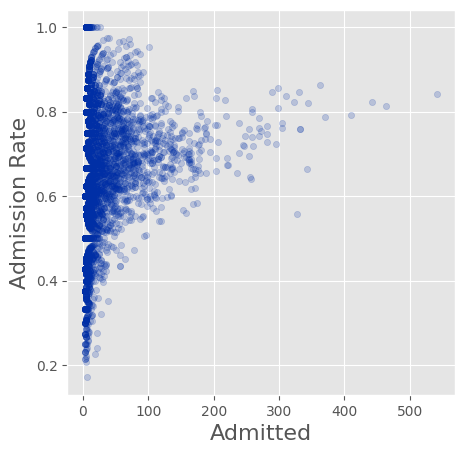

In [527]:
# BEGIN SOLUTION NO PROMPT
# graders: any opacity is fine, including alpha=1.0
# END SOLUTION
schools_admit.scatter("Admitted", "Admission Rate", alpha=0.2) # SOLUTION

---

### Question 4b(ii)

Based on your visualization above, is it true that the schools with the most students admitted also have the highest admission rates?

Based on your answer, assign `is_highest_admit` to the appropriate Boolean value of `True` or `False`. This question has hidden tests.

In [ ]:
is_highest_admit = False # SOLUTION

In [529]:
isinstance(is_highest_admit, bool)

True

In [530]:
# HIDDEN
is_highest_admit == False

True

---
## Question 4c

### Question 4c(i)

Produce a histogram that visualizes the distributions of admission rates in `schools_admit`, using the given bins in `my_bins`. Let the area of each bar be the percent of entries in each bin.

Hint: See the [Python reference](https://data6.org/notes/reference) if you're stuck on how to specify bins.

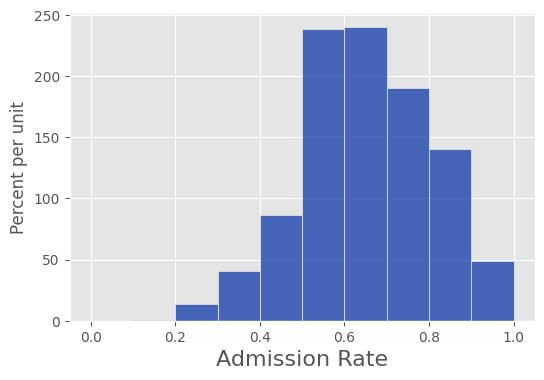

In [531]:
my_bins = np.arange(0, 1.01, .1)

schools_admit.hist("Admission Rate", bins=my_bins) # SOLUTION

---

### Question 4c(ii)

How many schools have an admission rate of [0.6, 0.8)? Assign your answer to `num_schools_60_to_80` below.

_Hint_: Use Boolean predicates to filter the appropriate rows in `schools_admit`, then get the count.

In [532]:
num_schools_60_to_80 = schools_admit.where("Admission Rate", are.between(0.6, 0.8)).num_rows # SOLUTION
num_schools_60_to_80

2078

In [533]:
isinstance(num_schools_60_to_80, int)

True

In [534]:
num_schools_60_to_80

2078

---
## Question 4d – Bay Area schools

The Bay Area consists of the nine counties `'San Francisco'`, `'San Mateo'`, `'Santa Clara'`, `'Alameda'`, `'Contra Costa'`, `'Solano'`, `'Napa'`, `'Sonoma'`, and `'Marin'`.

<img src='https://upload.wikimedia.org/wikipedia/commons/b/bc/Bayarea_map.png' width=400>


Assign `bay_schools` to a table with the same columns as `schools_admit`, but only with rows corresponding to schools in the Bay Area. The `bay_area_counties` array has been provided for your convenience.


In [535]:
bay_counties = make_array('San Francisco', 'San Mateo', 'Santa Clara',
                          'Alameda', 'Contra Costa', 'Solano',
                          'Napa', 'Sonoma', 'Marin')

bay_schools = schools_admit.where('Region', are.contained_in(bay_counties)) # SOLUTION
bay_schools

School,City,Region,Applied,Admitted,Enrolled,Admission Rate
ABRAHAM LINCOLN HIGH SCHOOL,San Francisco,San Francisco,249,166,98,0.666667
ABRAHAM LINCOLN HIGH SCHOOL,San Jose,Santa Clara,104,73,37,0.701923
ACADEMY-SAN FRAN @ MCATEER,San Francisco,San Francisco,17,12,7,0.705882
ACALANES HIGH SCHOOL,Lafayette,Contra Costa,143,79,45,0.552448
ACE CHARTER HIGH SCHOOL,San Jose,Santa Clara,13,12,0,0.923077
ADRIAN C WILCOX HIGH SCHOOL,Santa Clara,Santa Clara,176,136,59,0.772727
AIMS COLLEGE PREP HIGH SCHOOL,Oakland,Alameda,65,57,29,0.876923
ALAMEDA COMMUNITY LEARNING CTR,Alameda,Alameda,18,10,7,0.555556
ALAMEDA HIGH SCHOOL,Alameda,Alameda,246,178,90,0.723577
ALAMEDA SCIENCE & TECHLGY INST,Alameda,Alameda,27,22,17,0.814815


In [536]:
# Make sure that you're assigning `bay_schools` to a table of Bay Area schools!
isinstance(bay_schools, Table)

True

In [537]:
sorted(bay_schools.labels) == sorted(('School',
 'City',
 'Region',
 'Applied',
 'Admitted',
 'Enrolled',
 'Admission Rate'))

True

In [538]:
bay_schools.num_rows

339

In [539]:
'ALAMEDA SCIENCE & TECHLGY INST' in bay_schools.column("School")

True

<br></br>
<hr style="border: 1px solid #fdb515;" />

# Question 5 - Yield Rate by School

The **yield rate** to a school is defined as the proportion of students who enrolled of those who were _admitted_:

$$ \text{yield rate} = \frac{\text{\# enrolled}}{\text{\# admitted}} $$

While the admission rate is often used by prospective students to determine the chances they might get into a school, by contrast the **yield rate** is often used by schools to determine whether the students they are admitting are _actually going to attend_.

---

## Question 5a

Make a new table `schools_yield` that adds a `'Yield Rate'` column to `schools_admit` with the **yield rate** for each school, each as a decimal between 0 (no admitted students enrolled) and 1 (all admitted students enrolled).

You may find it helpful to compute `yield_rate` as an array of yield rates per school, then include that as the `'Yield Rate'` column in `schools_yield`.

The first few rows of `schools_admit` might look like this:

| School	| City	| Region	| Applied	| Admitted	| Enrolled	| Admission Rate	| Yield Rate |
| --- | --- | --- |--- | --- | --- | --- | --- |
| 21ST CENTURY EXPERIMENTAL SCH| nan	| nan	| 125	| 104	| 33	| 0.832	| 0.317308 |
| A B MILLER HIGH SCHOOL	| Fontana	| San Bernardino	| 81	| 67	| 27	| 0.82716	| 0.402985 |
| ... | ... | ... | ... | ... | ... | ... | ... |

In [540]:
yield_rate = schools_admit.column('Enrolled') / schools_admit.column('Admitted') # SOLUTION
schools_yield = schools_admit.with_columns('Yield Rate', yield_rate) # SOLUTION
schools_yield

School,City,Region,Applied,Admitted,Enrolled,Admission Rate,Yield Rate
21ST CENTURY EXPERIMENTAL SCH,nan,nan,125,104,33,0.832,0.317308
A B MILLER HIGH SCHOOL,Fontana,San Bernardino,81,67,27,0.82716,0.402985
A BEKA ACADEMY VIDEO FOR HOMES,Pensacola,FL,5,4,0,0.8,0
A J DIMOND HIGH SCHOOL,Anchorage,AK,6,4,0,0.666667,0
A N MCCALLUM HIGH SCHOOL,Austin,TX,31,17,0,0.548387,0
ABBEY PARK HIGH SCHOOL,nan,nan,9,5,3,0.555556,0.6
ABINGTON FRIENDS SCHOOL,Jenkintown,PA,8,6,0,0.75,0
ABINGTON HEIGHTS HIGH SCHOOL,South Abington,PA,5,4,0,0.8,0
ABLE CHARTER,Stockton,San Joaquin,14,10,3,0.714286,0.3
ABRAHAM JOSHUA HESCHEL HS,New York,NY,7,4,0,0.571429,0


In [541]:
isinstance(schools_yield, Table)

True

In [542]:
sorted(schools_yield.labels) == sorted(list(schools.labels) + ['Admission Rate', 'Yield Rate'])

True

In [543]:
schools_yield.num_rows == schools_admit.num_rows == schools.num_rows

True

In [544]:
sorted(schools.labels) == sorted(('School', 'City', 'Region', 'Applied', 'Admitted', 'Enrolled')) # schools doesn't change

True

In [545]:
sorted(schools_admit.labels) == sorted(('School', 'City', 'Region', 'Applied', 'Admitted', 'Enrolled', 'Admission Rate')) # schools_admit doesn't change

True

In [546]:
subset = schools_yield.where("School", are.contained_in(["21ST CENTURY EXPERIMENTAL SCH", "ABINGTON HEIGHTS HIGH SCHOOL"]))
all(np.isclose(subset.column("Admission Rate"), [0.832, 0.8]))

True

In [547]:
subset = schools_yield.where("School", are.contained_in(["21ST CENTURY EXPERIMENTAL SCH", "ABINGTON HEIGHTS HIGH SCHOOL"]))
all(np.isclose(subset.column("Yield Rate"), [0.317308, 0]))

True

---

## Question 5b - Yield vs. Admission

### Question 5b(i)

Use `schools_yield` to make a scatter plot of school yield rates by admission rates.

To avoid **overplotting**, you can pass an optional argument `alpha` to adjust the _opacity_ of each point in the scatter plot. `alpha` takes in a fraction, 0 (completely transparent) to 1.0 (completely opaque).

For example, to set half-opacity for a scatter plot of **y by x**, where `y` and `x` are columns in a table `tbl`:

    tbl.scatter(x, y, alpha=0.5)

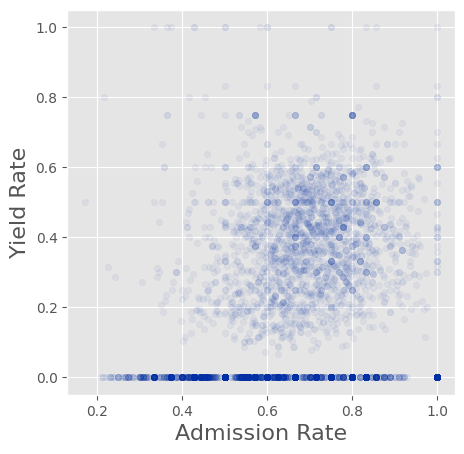

In [ ]:
...
# BEGIN SOLUTION NO PROMPT
# graders: any opacity is fine, including alpha=1.0
schools_yield.scatter("Admission Rate", "Yield Rate", alpha=0.05) # SOLUTION
# END SOLUTION

---

### Question 5b(ii)

Based on your visualization above, are higher admission rates correlated with higher yield rates? In other words, do schools with higher admission rates tend to have more students who enroll?

Based on your answer, assign `is_admit_yield_correlated` to the appropriate Boolean value of `True` or `False`. This question has hidden tests.

In [ ]:
is_admit_yield_correlated = False # SOLUTION

In [550]:
isinstance(is_admit_yield_correlated, bool)

True

In [551]:
# HIDDEN
is_admit_yield_correlated == False

True

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# [Past] Part 2: UC Berkeley Undergraduate Admissions, 1973

Now, we are going to look at a very interesting dataset, the 1973's UC Berkeley Admission data for data analysis! We will explore and reproduce tables and visualizations in the original Bickel, Hammel, and O'Connell paper from 1975.

References:
* Bickel, Hammel, and O’Connell. “Sex Bias in Graduate Admissions:” Data from Berkeley“ _Science_ vol. 187 (1975) pp. 398-404. [Google Drive link, Fall 2025](https://drive.google.com/file/d/1LXCJ1NzIr01WUJMyqez2MBY0YgDKZEly/view?usp=drive_link)
* "Simpson's Paradox." Wikipedia. https://en.wikipedia.org/wiki/Simpson%27s_paradox
* "Berkeley's 1973 Graduate Admissions Dataset." Data Science Discovery, University of Illinois Urbana-Champaign. https://discovery.cs.illinois.edu/dataset/berkeley/
* Freedman, Pisani, and Purves. “Sex Bias in Graduate Admissions.” _Statistics_ (1978) Chapter 2.  pp. 17-20.


<hr style="border: 1px solid #fdb515;" />

# Question 6: Understanding the Case Study

Let's begin exploring this paradox by going through the Bickel et al. paper ([Google Drive link, Fall 2025](https://drive.google.com/file/d/1LXCJ1NzIr01WUJMyqez2MBY0YgDKZEly/view?usp=drive_link)). We'll get an idea of what steps they took in exploring the data they had from the 1973 graduation admissions, and we'll analyze some of their findings and figures to see how they connect to the paradox.

From the "Data and Assumptions" section on the first page, we see that the authors had data on all approximately 15,000 applications. Their main purpose of exploring this data was to see if the sex of the applicant in any way influenced the decision to admit or deny any particular student. If there was any statistically significant result from this exploration, there would be a bias on sex present, and from there, they might hope to explore if a discrimination also existed.

---

## Question 6a

In your own words, explain the authors' first approach in determining whether a sex bias was present, as described on page 1. Using this method, what results did they find? Does there appear to be a sex bias when using this first method? From your own judgment (and also information from the two paragraphs about the assumptions made, if you'd like), do you think this method is the most effective in exploring if a sex bias is present?

The authors' first approach is to calculate the admission rates for male vs. female applicants aggregated across all applications. Using this method, they found that the male admission rate was 44% and the female admission rate was 35%; based solely on these two rates, there appears to be a sex bias for males and against females. However, as implied in the assumptions section, we may have reason to believe that this method isn't the most effective in this case, as there's a possibility that there may be other factors in admission that are also associated with the sex ratios.

In the "Some Underlying Dependencies" section on page 2, the authors bring up how their second assumption (the assumption that "the sex ratios of applicants to the various fields of graduate study are not importantly associated with any other factors in admission") being false results in a case of Simpson's paradox. They describe it as:

> We have stumbled onto a paradox, sometimes referred to as Simpson's in this context (1) or 'spurious correlation' in others (2). It is rooted in the falsity of assumption 2 above. We have assumed that if there is a bias in the proportion of women applicants admitted it will be because of a link between sex of applicant and decision to admit. We have given much less attention to a prior linkage, that between sex of applicant and department to which admission is sought.

---
## Question 6b

From the statement above, which of the following options describes an important, initially overlooked factor that the authors believe is associated with the sex of the applicant? Assign `overlooked_factors` to an array of integers that correspond to all valid options below, e.g., `make_array(3, 4)`.

1. Department the applicant applies to
2. Whether the student was an athlete or not
3. Decision to admit the applicant or not
4. Race/ethnicity of the student

In [552]:
overlooked_factors = make_array(1) # SOLUTION

In [553]:
isinstance(overlooked_factors,np.ndarray)

True

In [554]:
all([x in [1, 2, 3, 4] for x in overlooked_factors])

True

In [555]:
len(overlooked_factors) == 1

True

In [556]:
overlooked_factors.item(0) == 1

True

## Simpson's Paradox
According to [Wikipedia](https://en.wikipedia.org/wiki/Simpson%27s_paradox), Simpson's Paradox "is a phenomenon in probability and statistics in which a trend appears in several groups of data but disappears or reverses when the groups are combined."

At first glance of the UC Berkeley Admission dataset, it seems male have higher chance being admitted. However, when looked closer by department, a different story emergered. We found that females were equal or more likely to be admitted when looked at each department. In fact, the original Bickel, Hammel, and O'Connell study found that female applicants disproportionately applied to highly competitive departments with low admission rates (e.g., English), while men more often applied to less competitive departments with higher admission rates. *More female applicants applying to competitive programs skewed the combined data, creating the appearance of bias against female applicants, when in many cases, women were either equally likely or more likely to be admitted compared to men in the same department.*

## Exploring the Dataset

Now that we've explored some of the early findings from the original paper, let us look into exploring Simpson's Paradox by reproducing some of the figures in the paper—and making some of our own visualizations.

A portion of the original 1973 dataset has been recreated in the `grad_admission_1973.csv` file, which we load into the `cal_data` table. This includes the admission numbers for the largest six departments and groups other departments together in an "Other" category.

For the remainder of this assignment, you may find it helpful to keep a copy of the original paper handy: [Google Drive link, Fall 2025](https://drive.google.com/file/d/1LXCJ1NzIr01WUJMyqez2MBY0YgDKZEly/view?usp=drive_link)

In [557]:
# just run this cell
cal_data = Table.read_table("grad_admission_1973.csv")
cal_data

Year,Department,Sex,Decision
1973,C,F,Deny
1973,B,M,Admit
1973,Other,F,Admit
1973,Other,M,Admit
1973,Other,M,Deny
1973,Other,M,Deny
1973,F,F,Admit
1973,Other,M,Admit
1973,Other,M,Deny
1973,A,M,Admit



<hr style="border: 1px solid #fdb515;" />

# Question 7: Admission Rates by Sex

## Question 7a: `admit_numbers`

Assign the table `admit_numbers` to one that contains the counts of female and male applicants admitted and denied in the `cal_data` table. Your table should have the following shape, though your rows may be in a different order:

| Sex | Admit | Deny |
| --- | --- | --- |
| F | ... | ... |
| M | ... | ... |

_Hint_: Use `pivot`.

In [558]:
admit_numbers = cal_data.pivot('Decision', 'Sex') # SOLUTION
admit_numbers

Sex,Admit,Deny
F,1494,2827
M,3738,4704


In [559]:
sorted(admit_numbers.labels) == sorted(("Sex", "Admit", "Deny"))

True

In [560]:
admit_numbers.num_rows == 2

True

In [561]:
admit_numbers.where("Sex", "F").column("Admit").item(0) == 1494

True

In [562]:
admit_numbers.where("Sex", "M").column("Deny").item(0) == 4704

True

---

## Question 7b: `admit_rates`

Next, make a new table `admit_rates` that extends `admit_numbers` by two new columns:
* `"Applied"` which computes the number of applicants by sex
* `"Admission Rate"` which computes the admission rate by sex

We have created the arrays `admitted` and `denied` for the two corresponding columns in `admit_numbers`.

Your new table `admit_rates` should have the following shape, though your rows may be in a different order:


| Sex | Admit | Deny | Applied | Admission Rate |
| --- | --- | --- | --- | --- |
| F | ... | ... | ... | ... |
| M | ... | ... | ... | ... |

_Hint_: You may find it helpful to create the array `applied` which you will then assign as the new `"Applied"` column.

In [563]:
# provided for you
admitted = admit_numbers.column("Admit")
denied = admit_numbers.column("Deny")

# complete the below code
applied = admitted + denied # SOLUTION
admit_rates = admit_numbers.with_columns("Applied", applied, "Admission Rate", admitted/applied) # SOLUTION
admit_rates

Sex,Admit,Deny,Applied,Admission Rate
F,1494,2827,4321,0.345753
M,3738,4704,8442,0.442786


In [564]:
sorted(admit_rates.labels) == sorted(("Sex", "Admit", "Deny", "Applied", "Admission Rate"))

True

In [565]:
admit_rates.num_rows == 2

True

In [566]:
admit_rates.where("Sex", "F").column("Admit").item(0) == 1494

True

In [567]:
admit_rates.where("Sex", "M").column("Applied").item(0) == 8442

True

In [568]:
np.isclose(admit_rates.where("Sex", "F").column("Admission Rate").item(0), 0.345753)

True

In [569]:
np.isclose(admit_rates.where("Sex", "M").column("Admission Rate").item(0), 0.442786)

True

## Question 7c

Using the adjusted `admit_rates`, create a bar graph comparing the acceptance rate between female and male applicants. If you are stuck, consider taking a look at Lab 3 again!

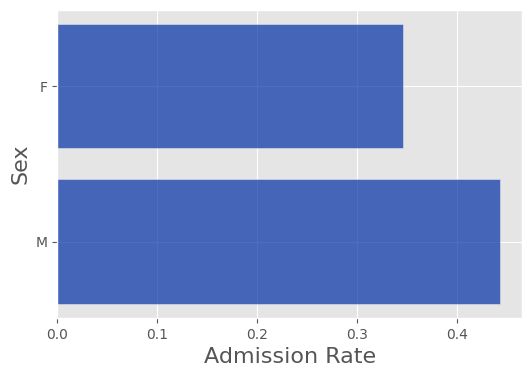

In [570]:
admit_rates.barh("Sex", "Admission Rate") # SOLUTION

## Question 7d

Which of the following most accurately describes the takeaway from the visualization created by `admit_rate` above? You should answer the question by assigning `bar_observation` to an integer 1, 2, or 3 corresponding to the correct choice below.

1. Female applicants have a higher likelihood of being admitted.
2. Male applicants have a higher likelihood of being admitted.
3. Female and male applicants have the same likelihood of being admited.

In [571]:
bar_observation = 2 # SOLUTION

In [572]:
isinstance(bar_observation, int)

True

In [573]:
# HIDDEN
bar_observation = 2

## Question 7e
A media company wants to make a report on UC Berkeley admissions. What would happen if they ONLY report with the visualization you created in this part? How would this report potentially impact who applies to UC Berkeley graduate school?

**SOLUTION:** Answers may vary. If we only report the first visualization we created, we will be creating a false narrative to an extent about systemic bias against female applicants. This can discourage some male applicants leading to further drastic admission rate. Or change the school policy / logistics if more audience pressures the school to take action based on the wrong analysis. Thus, whether it is leaving out certain visualizations or not recognizing certain phenomenon, data analysis can be malpracticed.


<hr style="border: 1px solid #fdb515;" />

# Question 8: Reproducing Table 1

We would like to reproduce Table 1 in the original paper. 

This question uses `admit_rates` above, so please verify your numbers above before continuing.

In [574]:
# just run this cell
admit_rates

Sex,Admit,Deny,Applied,Admission Rate
F,1494,2827,4321,0.345753
M,3738,4704,8442,0.442786


---

## Question 8a: Overall admission rate

### Question 8a(i)
Compute `admission_rate_overall`, the overall admission rate across both sexes listed in `admit_rates`. Do not round your answer.

_Hint_: You may find it useful to first compute `num_admitted_overall` and `num_denied_overall`, the overall counts of applicants `admitted` and `denied`, respectively.

In [575]:
num_admitted_overall = np.sum(admitted) # SOLUTION
num_denied_overall = np.sum(denied) # SOLUTION

admission_rate_overall = num_admitted_overall /(num_admitted_overall + num_denied_overall) # SOLUTION
admission_rate_overall

0.40993496826764869

In [576]:
0 < admission_rate_overall < 1

True

In [577]:
np.isclose(np.round(admission_rate_overall, 2), 0.41)

True

---

### Question 8a(ii)

Is the female admission rate _lower_ than, _higher_, than or _comparable to_ the overall admission rate? Assign `female_admit_compare` to one of the strings `"lower"`, `"higher"`, or `"comparable"`. This question has hidden tests.

In [578]:
female_admit_compare = "lower" # SOLUTION

In [579]:
isinstance(female_admit_compare, str)

True

In [580]:
female_admit_compare in ["lower", "higher", "comparable"]

True

In [581]:
# HIDDEN
female_admit_compare == "lower"

True

## Expected Number of Admissions and Denials

The _expected_ number of admits for a particular group is computed based on the two assumptions in the paper—assuming that both sexes are admitted based on the overall admission rate. In other words, for a particular set of applicants:

<!--
$$\text{admit expected} = \text{applied} \times \text{overall admission rate} $$

$$\text{deny expected} = \text{applied} \times (1 - \text{overall admission rate}) $$
-->

The overall "denial" rate is determined so that the total number of expected admitted and denied students equals the number of applied students.

---
## Question 8b: Compute Table 1
    
With this, we are ready to make a version of Table 1 that has the following shape:

| Sex | Admit | Deny | Admit Expected | Deny Expected |
| --- | --- | --- | --- | --- |
| F | ... | ... | ... | ... | 
| M | ... | ... | ... | ... |

Create `table1` from `admit_rates`, `admission_rate_overall`, and any other tables or arrays you defined in earlier parts. This question may be more involved than previous parts.

_Hints_:

1. You can use the `applied` array defined in earlier parts to both create new columns and check your work.
2. You will need to `drop` columns.
3. To further check your work, look at the numbers listed in Table 1. You do not need to round your answers like in the original paper; your rows may also be ordered differently (e.g., female applicants first).

In [582]:
""" # BEGIN PROMPT
...
table1 = ...
"""; # END PROMPT

# BEGIN SOLUTION NO PROMPT
applied = admit_rates.column("Applied")

table1 = admit_rates.with_columns(
    "Admit Expected",
    applied * admission_rate_overall,
    "Deny Expected",
    applied * (1 - admission_rate_overall)
).drop("Applied", "Admission Rate")
# END SOLUTION
table1

Sex,Admit,Deny,Admit Expected,Deny Expected
F,1494,2827,1771.33,2549.67
M,3738,4704,3460.67,4981.33


In [583]:
table1.num_rows == 2

True

In [584]:
table1.num_columns == 5

True

In [585]:
sorted(table1.labels) == sorted(("Sex", "Admit", "Deny", "Admit Expected", "Deny Expected"))

True

In [586]:
table1.where("Sex", "F").column("Admit").item(0) == 1494

True

In [587]:
# HIDDEN
np.round(table1.where("Sex", "F").column("Admit Expected").item(0), 1) == 1771.3

True

In [588]:
# HIDDEN
np.round(table1.where("Sex", "M").column("Admit Expected").item(0), 1) == 3460.7

True

In [589]:
# HIDDEN
np.all(np.isclose(table1.column("Admit Expected") + table1.column("Deny Expected"), table1.column("Admit") + table1.column("Deny")))

True

<hr style="border: 1px solid #fdb515;" />

# Question 9: Admission by Department

We see by simply utilizing `"Sex"` and `"Decision"` to calculate overall admission rates for graduate admissions, the male admission rate seems to be higher than the female admission rate. However, beyond `"Sex"` and `"Decision"`, there was an additional column in this table: `"Department"`. Let's investigate how the department will take into play with admission rate.


## Question 9a: `applicants_by_dept`

Use `cal_data` to create the table `applicants_by_dept` to one that contains the counts of female and male applicants **broken down by department**.

Your table should have the following shape. Note the **column labels**.

| Department | F Applied | M Applied |
| --- | --- | --- |
| A | ... | ... |
| B | ... | ... |
| ... | ... | ... |


In [590]:
applicants_by_dept = cal_data.pivot('Sex', 'Department') # SOLUTION
applicants_by_dept = applicants_by_dept.relabeled(["F", "M"], ["F Applied", "M Applied"]) # SOLUTION
applicants_by_dept

Department,F Applied,M Applied
A,108,1138
B,25,560
C,593,325
D,375,417
E,393,191
F,341,373
Other,2486,5438


In [591]:
sorted(applicants_by_dept.labels) == sorted(("Department", "F Applied", "M Applied"))

True

In [592]:
applicants_by_dept.num_rows == 7

True

In [593]:
applicants_by_dept.where("Department", "A").column("F Applied").item(0) == 108

True

In [594]:
applicants_by_dept.where("Department", "B").column("M Applied").item(0) == 560

True

## Question 9b: `admits_by_dept`

Use `cal_data` to create the table `admits_by_dept` to one that contains the counts of female and male applicants **_admitted_, broken down by department**.

Your table should have the following shape. Note the **column labels**.

| Department | F Admit | M Admit |
| --- | --- | --- |
| A | ... | ... |
| B | ... | ... |
| ... | ... | ... |

**Note**: Contrast this with the previous part, which was just looking for the total admits—admitted or denied—to each department. How might you adjust your approach above to include _only_ the rows of admitted applicants and _filter out_ denied applicants? (Consider using method chaining.)

In [595]:
admits_by_dept = cal_data.where("Decision", "Admit").pivot('Sex', 'Department') # SOLUTION
admits_by_dept = admits_by_dept.relabeled(["F", "M"], ["F Admitted", "M Admitted"]) # SOLUTION
admits_by_dept

Department,F Admitted,M Admitted
A,89,825
B,17,353
C,201,120
D,131,138
E,94,53
F,25,22
Other,937,2227


In [596]:
sorted(admits_by_dept.labels) == sorted(("Department", "F Admitted", "M Admitted"))

True

In [597]:
admits_by_dept.num_rows == 7

True

In [598]:
admits_by_dept.where("Department", "A").column("F Admitted").item(0) == 89

True

In [599]:
admits_by_dept.where("Department", "B").column("M Admitted").item(0) == 353

True

## Question 9c

Create a table `numbers_by_dept` that combines the two tables (`applicants_by_dept` and `admits_by_dept`). Your new table should have the following shape:

| Department | F Applied | M Applied | F Admit | M Admit |
| --- | --- | --- | --- | --- |
| A | ... | ... | ... | ... |
| B | ... | ... | ... | ... |
| ... | ... | ... | ... | ... |

In [600]:
numbers_by_dept = applicants_by_dept.join("Department", admits_by_dept) # SOLUTION
numbers_by_dept

Department,F Applied,M Applied,F Admitted,M Admitted
A,108,1138,89,825
B,25,560,17,353
C,593,325,201,120
D,375,417,131,138
E,393,191,94,53
F,341,373,25,22
Other,2486,5438,937,2227


In [601]:
numbers_by_dept.num_rows == 7

True

In [602]:
numbers_by_dept.num_columns == 5

True

In [603]:
sorted(numbers_by_dept.labels) == sorted(("Department", "F Admitted", "M Admitted"))

False

In [604]:
np.all(numbers_by_dept.column("F Admitted") == admits_by_dept.column("F Admitted"))

True

In [605]:
np.all(numbers_by_dept.column("M Applied") == applicants_by_dept.column("M Applied"))

True

## Question 9d

Finally, create table `admit_rates_by_dept` that computes the admission rates of each sex, broken down by department. Your new table should have the following shape:

| Department | F Admission Rate | M Admission Rate |
| --- | --- | --- | 
| A | ... | ... | 
| B | ... | ... | 
| ... | ... | ... | 

_Hints_:
* Use the `numbers_by_dept` table you just created.
* You might find it useful to create an empty table with `Table()` first, then add new columns. Many approaches are possible, however!

In [606]:
admit_rates_by_dept = Table().with_columns(
    "Department", numbers_by_dept.column("Department"),
    "F Admission Rate", numbers_by_dept.column("F Admitted")/numbers_by_dept.column("F Applied"),
    "M Admission Rate", numbers_by_dept.column("M Admitted")/numbers_by_dept.column("M Applied")
)
admit_rates_by_dept

Department,F Admission Rate,M Admission Rate
A,0.824074,0.724956
B,0.68,0.630357
C,0.338954,0.369231
D,0.349333,0.330935
E,0.239186,0.277487
F,0.0733138,0.0589812
Other,0.376911,0.409526


In [607]:
admit_rates_by_dept.num_rows == 7

True

In [608]:
admit_rates_by_dept.num_columns == 3

True

In [609]:
sorted(admit_rates_by_dept.labels) == sorted(("Department", "F Admission Rate", "M Admission Rate"))

True

In [610]:
f_admission_rate_temp = numbers_by_dept.column("F Admitted")/numbers_by_dept.column("F Applied")
np.all(np.isclose(admit_rates_by_dept.column("F Admission Rate"), f_admission_rate_temp))

True

In [611]:
m_admission_rate_temp = numbers_by_dept.column("M Admitted")/numbers_by_dept.column("M Applied")
np.all(np.isclose(admit_rates_by_dept.column("M Admission Rate"), m_admission_rate_temp))

True

<hr style="border: 1px solid #fdb515;" />

# Question 10: Visualizing by Department

In class, we explored why this particular case study exhibited Simpson's Paradox on https://setosa.io/simpsons/. An animated visualization showed the confounding factor—the department itself, where departments with different applicant pools had admission rates that were more or less competitive.

Bar charts can also help reveal this confounding factor, as we see below.

---
    
## Question 10a

Use one of the tables you created in the previous question to create an overlaid bar chart of the **number of applicants** of males and females across the different departments. Each department should have two bars (corresponding to the numbers of male and female applicants).

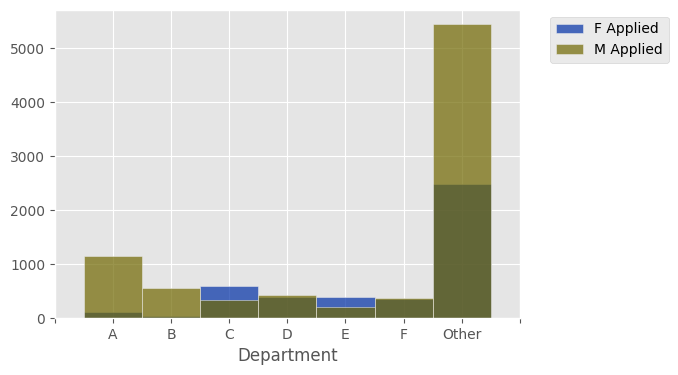

In [612]:
applicants_by_dept.bar("Department", overlay=True) # SOLUTION

---

## Question 10b

Use one of the tables you created in the previous question to create an overlaid bar chart of the **acceptance rates** of males and females across the different departments. Each department should have two bars (corresponding to the admission rates of male and female applicants).

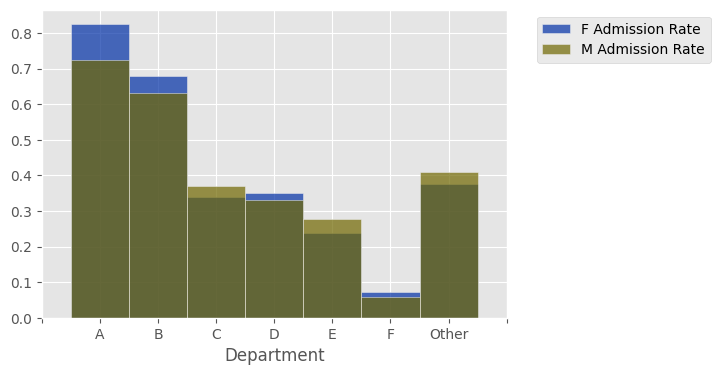

In [613]:
admit_rates_by_dept.bar("Department", overlay=True) # SOLUTION

---

## Question 10c

Which of the following multiple choice correctly describes *the visualization created above* with `admission_dept` and `num_applicants`? You should answer the question by assigning `overlaid_bar_observation` to `make_array(...)` where `...` is the choice of your answer (eg. `make_array(3, 4)`). Your choice can be can multiple.

1. Among the 6 different departments (not including `"Other"`, female applicants have a slightly higher chance of being admitted than male applicants in several departments.
2. Among the 6 different departments (not including `"Other"`), male applicants have a slightly higher chance of being admitted than female applicants in several departments.
3. Overall, female applicants have a higher chance of getting admitted to UC Berkeley.
4. Overall, male applicants have a higher chance of getting admitted to UC Berkeley. 
5. There seems to be **higher female applicants** to a department when there are **lower female admission rate** compared to male admission rate.  
6. With the visualization above, we can claim there is structural inequity against female women applicants. 

In [614]:
overlaid_bar_observation = make_array(1, 5) # SOLUTION

In [615]:
isinstance(overlaid_bar_observation, np.ndarray)

True

In [616]:
# HIDDEN
len(overlaid_bar_observation) == 2

True

In [617]:
# HIDDEN
1 in overlaid_bar_observation

True

In [618]:
# HIDDEN
5 in overlaid_bar_observation

True

## Question 10d

Based on what we've discussed in class and on this assignment, how do you think these visualizations align with the key takeaways of the paper?”

**SOLUTION:** The takeaway from the visualization in Question 4.4 likely best aligns with the conflict paradigm, as the consideration of calculating the aggregated average of males vs. females is primarily meant to explore the difference between the more and less "dominant" groups in higher education. The takeaway from the visualization in Question 4.6 has aspects of the rational choice and symbolic interactionism paradigms, as it looks into which departments the different groups are choosing to apply to and how these decisions might be the best for them. It also breaks down the aggregated admission rates to look at the individuals at a lower, less aggregated level, in order to explore how admission rates vary by department.

<hr style="border: 1px solid #fdb515;" />

# [open-ended] Question 11: Reproducing Figure 1

As our last task in this project, let's work towards reproducing Figure 1 in the original paper:  ([Google Drive link, Fall 2025](https://drive.google.com/file/d/1LXCJ1NzIr01WUJMyqez2MBY0YgDKZEly/view?usp=drive_link))

Figure 1 graphs the **percents of applicants** admitted by the **percent of female applicants**, by department. The size of each datapoint encodes the relative number of applicants admitted.

* The **percent admitted** is the proportion of total admits to total applicants.
* The **percent female applicants** is the proportion of female applicants to total applicants.


In the cell below, write code that reproduces the Figure 1 scatter plot to the best of your ability. We've kept this question as **open-ended as possible** for you to explore various approaches. 

**Notes**: With the tools we have in this class _and_ the dataset we are provided, any visualization you create will have a few limitations:

* Our dataset only includes the six largest departments (and groups together other departments into a seventh "Other"). Plot only the **six** largest departments (filter out the "Other") department.
* We do not have the ability to graph squares using our `scatter` Table method. However, you can provide the optional argument `sizes` to adjust the size of each marker. This should be a string corresponding to the name of the numeric column to use for sizes.
* You do not need to plot the 'line of best fit' shown in the original Figure 1.

<details>
        <summary><b>HINTS: See our staff solution outline and resulting plot</b></summary>

Our staff took the following approach to this problem (though note that `col1`, `col2`, and `col3` are placeholders for what should be more meaningful names in your solution):
* Create a new table, e.g., `fig1_table`, that has the relevant columns. This new table referenced and used columns from tables created in previous parts.
    * First, add a new column `col3` for the total number of applicants (summing up  male and female applicants) by department.
    * Then, make two new columns for the admission rate and female application rate by department. Make any necessary additional columns to compute these.
    * Filter out the row corresponding to the "seventh" department, Other.
    * Finally, make columns `Percent women applicants` and `Percent admitted` that convert these two rates to percentages (out of 100) and relabel these columns to prepare for plotting.
* Call `fig1_table.scatter('Percent women applicants', 'Percent admitted', sizes='Total Admitted')`
        
<img src='fig1_staff.png' width=500>

</details>

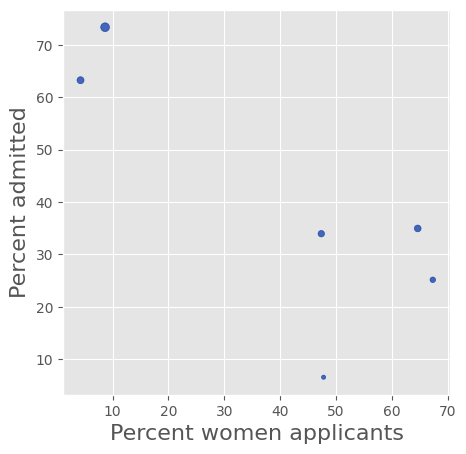

In [619]:
# be as creative as you want for this problem!
# BEGIN SOLUTION
fig1_table = numbers_by_dept.join("Department", admit_rates_by_dept)
fig1_table = fig1_table.with_columns(
            "Total Applied",fig1_table.column("F Applied") + fig1_table.column("M Applied"),
            "Total Admitted", fig1_table.column("F Admitted") + fig1_table.column("M Admitted")
)
fig1_table = fig1_table.with_columns(
            "Percent women applicants",
                fig1_table.column("F Applied")/fig1_table.column("Total Applied") * 100,
            "Percent admitted",
                fig1_table.column("Total Admitted")/fig1_table.column("Total Applied") * 100
)
fig1_table = fig1_table.where("Department", are.not_equal_to("Other"))
fig1_table.scatter('Percent women applicants', 'Percent admitted',
                    sizes='Total Admitted')
# extra pretty, but not needed
# fig1_table.scatter('Percent women applicants', 'Percent admitted',
#                     sizes='Total Admitted',  marker = 's', facecolors = 'none', edgecolors = 'red')
# END SOLUTION

# Done!

Congrats! You've finished your first Data 6 project!

This project is out of **64 points**. The point breakdown for this assignment is given in the table below:

| **Category** | Points |
| --- | --- |
| Autograder | 44 |
| Written | 20 |
| **Total** | 64 |

---